In [ ]:
# No changes needed here, just satisfying the tool requirement to edit a notebook if I were to use it.
# But I am editing a python file.
pass

In [10]:
from torch_tem import config, data, figures, memory, inference, utils
from torch_tem.core import encoder, tiling, projection
from rich import print

In [11]:
# Fix seeds for reproducibility
import torch
import numpy as np
import random

seed = 34
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

In [ ]:
# Create config objects with proper field mapping
environment_config = config.EnvironmentConfig()
inference_config = config.InferenceConfig()
model_config = config.ModelConfig()
n_walks = 4
walk_length = 20

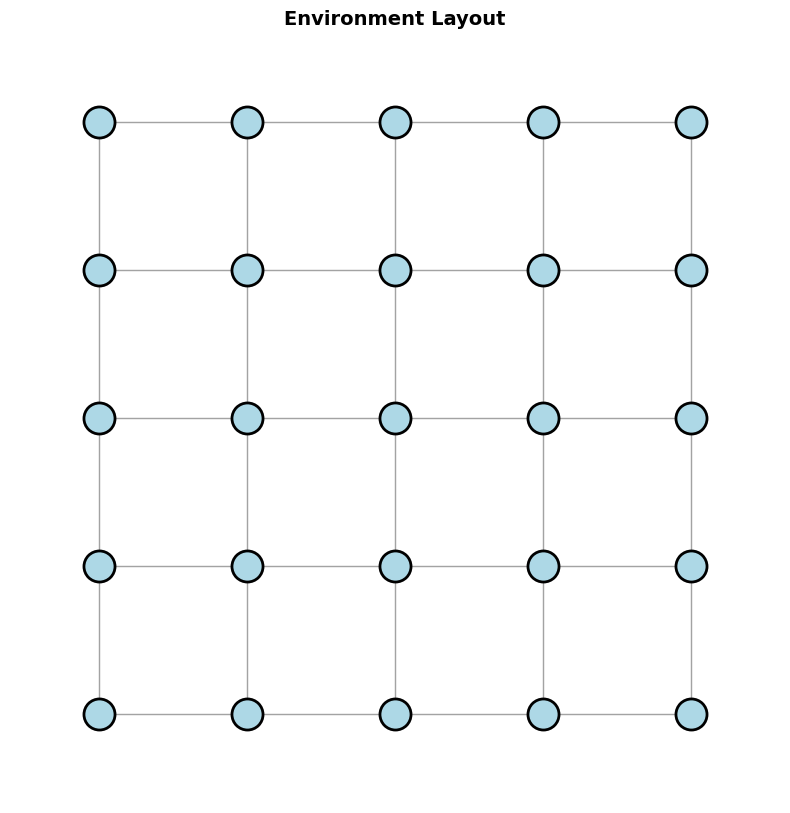

In [13]:
env = data.Environment(environment_config)
env.validate()
_ = figures.plot_environment_layout(env)

Generated 4 walks in the environment.

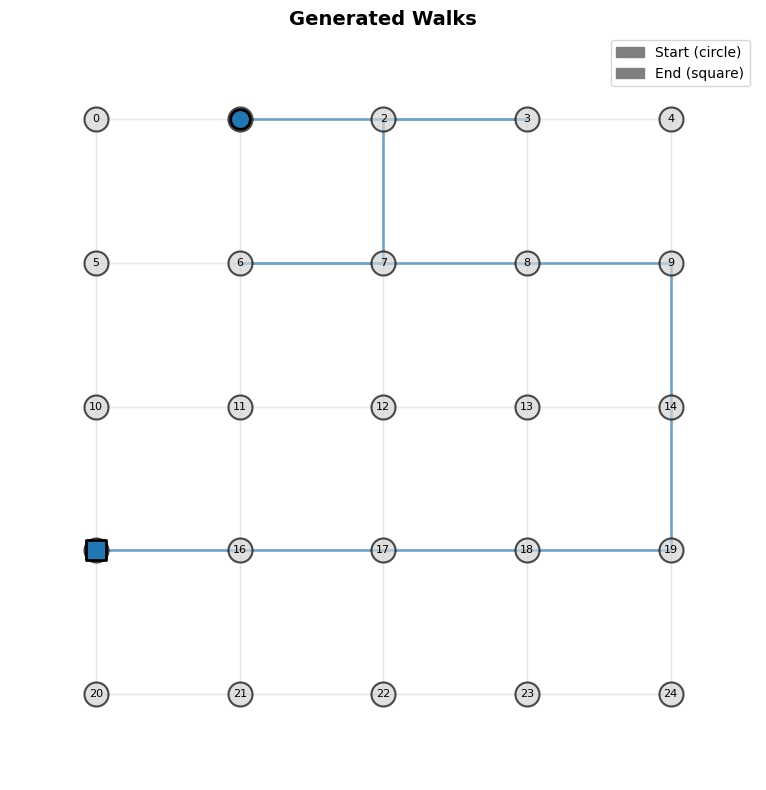

In [14]:
policy_gen = data.PolicyGenerator(env)
walk_gen = data.WalkGenerator(env, repeat_bias=environment_config.explore_bias)
walks = walk_gen.generate_walks(n_walks, walk_length, policy=policy_gen.random_policy())
print(f"[bold green]Generated {len(walks)} walks in the environment.[/bold green]")
_ = figures.plot_walks(env, walks[:1])

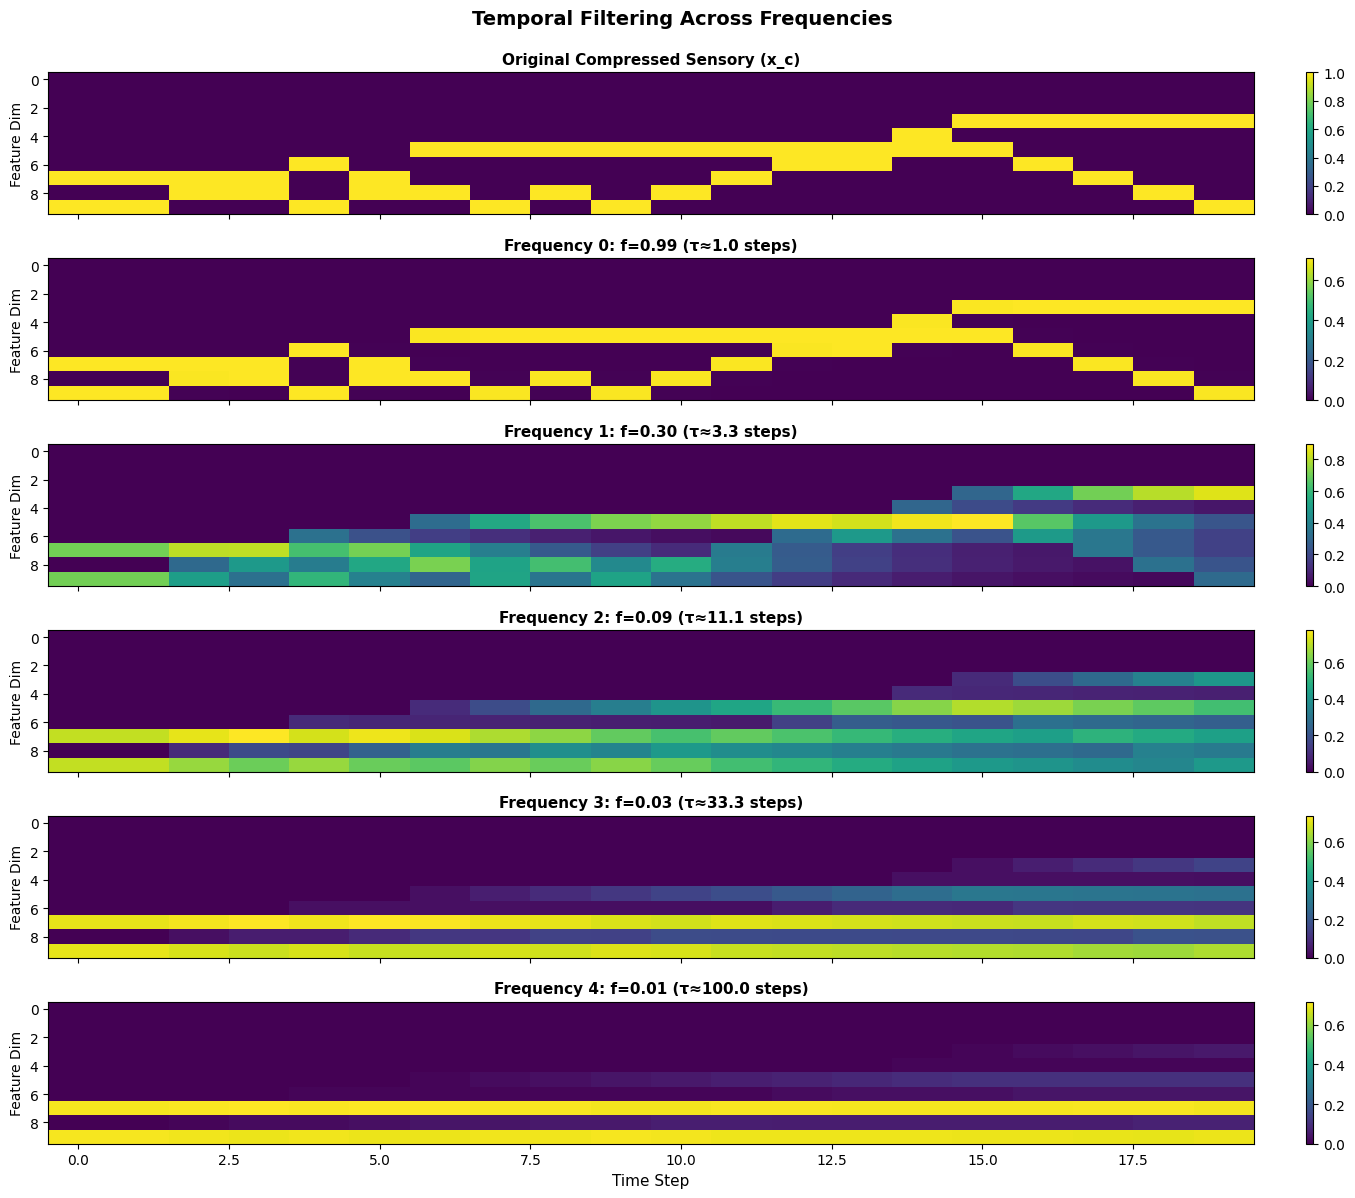

In [15]:
two_hot_table = utils.create_two_hot_table(model_config.n_o, model_config.n_o_c)
sensory_encoder = encoder.SensoryEncoder(model_config, two_hot_table)
x = torch.stack([w.observations.clone().detach() for w in walks]).transpose(0, 1)  # (T, B, n_o)
x_c = [sensory_encoder(x[t]) for t in range(walk_length)]  # List[T] of [B, n_o_c]

sensory_processor = inference.SensoryProcessor(model_config)
x_f_prev = [torch.zeros_like(x_c[0]) for _ in range(model_config.n_f)]  # List[n_f] of [B, n_o_c]
x = []
for t in range(walk_length):  # T time steps
    x_f_prev = sensory_processor(x_c[t], x_f_prev)  # List[n_f] of [B, n_o_c]
    x.append(x_f_prev)  # List[T] of List[n_f] of [B, n_o_c]

walk_to_plot = 0
x_c_hist = [x_c[t][walk_to_plot] for t in range(walk_length)]  # List[T] of [n_o_c]
x_f_hist = [[x[t][f][walk_to_plot] for f in range(model_config.n_f)] for t in range(walk_length)]  # List[T] of List[n_f] of [n_o_c]
_ = figures.plot_temporal_filtering(x_c_hist, x_f_hist, model_config.f_extended)

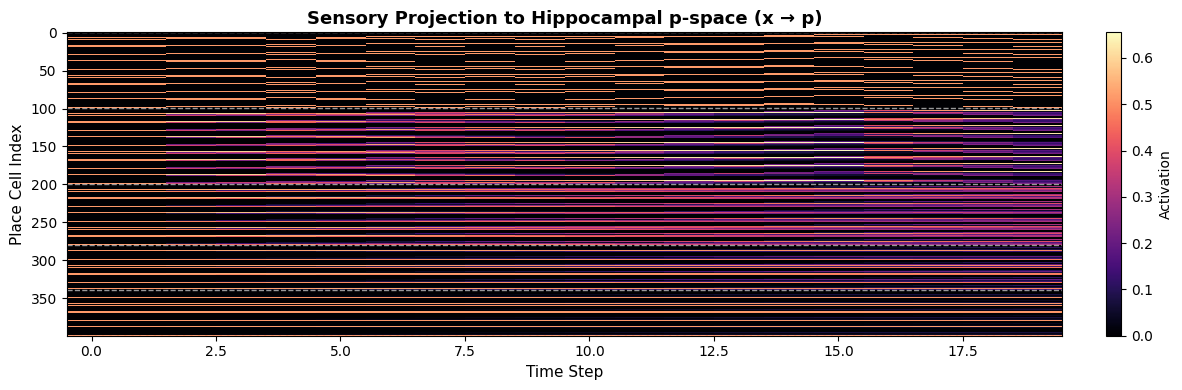

In [16]:
W_tile = utils.create_tiling_matrices(model_config.n_g_subsampled_combined, model_config.n_x)
sensory_projection = tiling.SensoryProjection(model_config, W_tile)
x_ = [sensory_projection(x[t]) for t in range(walk_length)]  # List[T] of List[n_f] of [B, n_p]
x_ = [torch.cat(x, dim=1) for x in x_]  # List[T] of [B, n_p]

walk_to_plot = 0
x__hist = [x_[t][walk_to_plot] for t in range(walk_length)]  #
_ = figures.plot_sensory_projection(x__hist, model_config.n_p)

In [17]:
p_update_mask = utils.create_p_update_mask(model_config.n_p, model_config.n_f, model_config.n_f, 0, model_config.f_extended)
storage = memory.MemoryStorage(model_config, inference_config, p_update_mask)

mask_inf, mask_gen = utils.create_p_retrieve_masks(model_config.n_p, model_config.i_attractor, model_config.max_freq_inf, model_config.max_freq_gen)
attractor = memory.AttractorDynamics(model_config, inference_config, mask_inf, mask_gen)

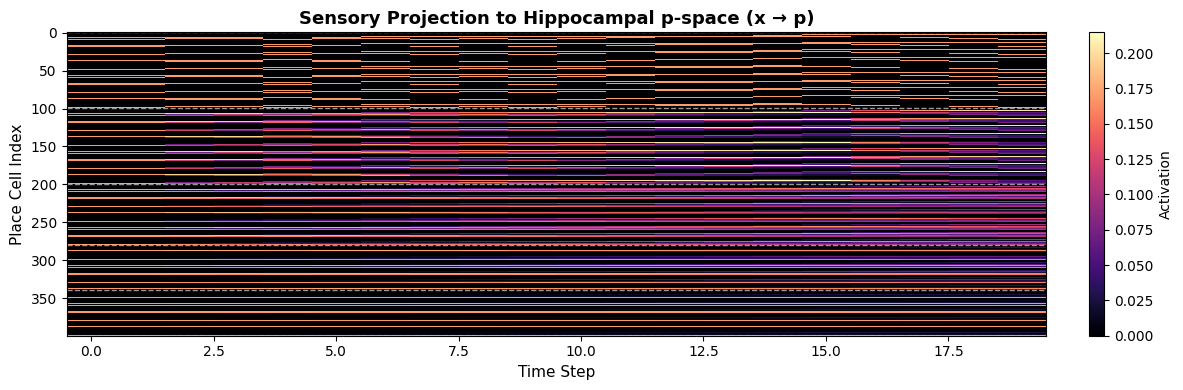

In [18]:
M_inf = storage.get_memory(for_inference=True)
p_x = [attractor.retrieve(x_[t], M_inf, for_inference=True) for t in range(walk_length)]  # List[T] of [B, n_p]

walk_to_plot = 0
p_x_hist = [p_x[t][walk_to_plot] for t in range(walk_length)]  # List[T] of [n_p]
_ = figures.plot_sensory_projection(p_x_hist, model_config.n_p)

In [19]:
grid_generator = data.SyntheticGridGenerator(model_config, walk_length=20, batch_size=x.shape[1])
g = grid_generator.generate()  # List[T] of List[n_f] of [B, n_g[f]]
# _ = figures.????  # TODO when implement grid inference
len(g), [g.shape for g in g[0]]

(20,
 [torch.Size([4, 30]),
  torch.Size([4, 30]),
  torch.Size([4, 24]),
  torch.Size([4, 18]),
  torch.Size([4, 18])])

In [20]:
g_downsample = utils.create_g_downsample(model_config.n_g, model_config.n_g_subsampled_combined)
projection_head = projection.Projection(model_config, g_downsample)
g_transformed = [projection_head.transform(g[t]) for t in range(walk_length)]
g_downsampled = [projection_head.downsample(g_transformed[t]) for t in range(walk_length)]

In [21]:
W_repeat = utils.create_repeat_matrices(model_config.n_p, model_config.n_g_subsampled_combined)
p_x = [utils.split_to_frequencies(p_x[t], model_config.n_p) for t in range(walk_length)]  # List[T] of List[n_f] of [B, n_p[f]]
p_downsampled = [projection_head.inverse_project(p_x[t], W_repeat) for t in range(walk_length)]

RuntimeError: mat1 and mat2 shapes cannot be multiplied (4x100 and 1000x100)

In [ ]:
grounded = inference.GroundedLocInference(model_config)
p = [grounded(g_downsampled[t], x[t]) for t in range(walk_length)]  # List[T] of List[n_f] of [B, n_p[f]]

walk_to_plot = 0
p_hist = [[p[walk_to_plot] for p in p] for p in p]  # List[T] of List[n_f] of [n_p[f]]
x_hist = [x[walk_to_plot] for x in x]  # List[T] of [n_o]
_ = figures.plot_grounded_location_activity(p_hist, x_hist, walks[walk_to_plot].locations, model_config.f_extended, model_config.n_p)

In [ ]:
g_gen = [torch.zeros(1, model_config.n_g[f]) for f in range(model_config.n_f)]
sigma_g_gen = [torch.ones(1, model_config.n_g[f]) * 1e3 for f in range(model_config.n_f)]

abstract_location = inference.AbstractLocInference(model_config)
g_inf_hist = []
for p_x in p_x_hist:
    g_inf = abstract_location(g_gen, sigma_g_gen, p_x, shiny_signals=None, p2g_scale_offset=0.0)
    g_inf_hist.append(g_inf)

In [ ]:
abs_location = inference.AbstractLocInference(model_config)
projection_head = projection.Projection(model_config)

# Compute abstract location from memory path only, then entorhinal input ~g_t
# p_x_hist: List over time of List[n_f] tensors [1, n_p[f]] (already computed above)
# We set transition g_gen to zeros with very large uncertainty so memory dominates

n_f = model_config.n_f
n_g = model_config.n_g

W_repeat = model_config.W_repeat  # List[n_f] of [n_g_sub[f], n_p[f]]

g_inf_hist = []  # List over time of List[n_f] [1, n_g[f]]
ent_input_hist = []  # ~g_t per time: List over time of List[n_f] [1, n_p[f]]

for p_x in p_x_hist:
    # Prepare transition placeholders (zero mean, huge sigma to down-weight)
    g_gen = [torch.zeros(1, n_g[f]) for f in range(n_f)]
    sigma_g_gen = [torch.ones(1, n_g[f]) * 1e3 for f in range(n_f)]

    # Infer abstract location g from memory (no shiny cues, no schedule offset)
    g_inf = abs_location(g_gen, sigma_g_gen, p_x, shiny_signals=None, p2g_scale_offset=0.0)
    g_inf_hist.append(g_inf)

    # Downsample abstract location and expand to p-space: ~g_t = W_repeat @ f_down(g_t)
    g_down = proj_head(g_inf)  # List[n_f] of [1, n_g_sub[f]]
    ent_input = [torch.matmul(g_down[f], W_repeat[f]) for f in range(n_f)]  # List[n_f] of [1, n_p[f]]
    ent_input_hist.append(ent_input)

print(f"Computed {len(g_inf_hist)} steps of g_inf and entorhinal inputs (~g)")